In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seeds(seed=42):
    """
    Blocca il caso per rendere tutto riproducibile (Richiesta del Prof).
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"✅ Random Seeds fissati a {seed}. I risultati saranno riproducibili!")

# Eseguiamo la funzione
set_seeds(42)

c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


✅ Random Seeds fissati a 42. I risultati saranno riproducibili!


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.decomposition import PCA
import os
import joblib

# ==============================================================================
# ⚙️ CONFIGURAZIONE
# ==============================================================================
BASE_PATH = "."   
OUT_PATH = "data_ready"       
os.makedirs(OUT_PATH, exist_ok=True)
os.makedirs("saved_models", exist_ok=True)

FILE_COORDS = os.path.join(BASE_PATH, "coordinates_processed.csv")
FILE_FORCES = os.path.join(BASE_PATH, "forces_processed.csv")
FILE_VELS =   os.path.join(BASE_PATH, "velocity_processed.csv")

LATENT_DIM = 32

print("🚀 RIPARAZIONE DATASET (Autoencoder Linear Fix)")
print("===================================================")

# ==============================================================================
# FASE A: AUTOENCODER (CORRETTO con Linear Output)
# ==============================================================================
print("\n🔧 FASE A: Training Autoencoder (Versione Corretta)...")

if not os.path.exists(FILE_COORDS): raise FileNotFoundError(f"❌ Manca {FILE_COORDS}")

df_coords = pd.read_csv(FILE_COORDS)
data_coords = df_coords.values
input_dim = data_coords.shape[1]

# --- ARCHITETTURA MODIFICATA ---
inp = layers.Input(shape=(input_dim,))
e = layers.Dense(128, activation='relu')(inp)
e = layers.Dense(64, activation='relu')(e)
latent = layers.Dense(LATENT_DIM, activation='linear', name="bottleneck")(e)

d = layers.Dense(64, activation='relu')(latent)
d = layers.Dense(128, activation='relu')(d)

# ⚠️ LA FIX È QUI SOTTO: 'linear' invece di 'sigmoid' per superare 1.0
out = layers.Dense(input_dim, activation='linear')(d) 

ae = models.Model(inp, out)
ae.compile(optimizer='adam', loss='mse')

# Aumentiamo un po' le epoche per farlo convergere meglio ora che può farlo
print("   -> Training in corso (20 epoche)...")
ae.fit(data_coords, data_coords, epochs=20, batch_size=64, verbose=0, shuffle=True)

# Salvataggio e Estrazione
encoder = models.Model(inp, latent)
latent_values = encoder.predict(data_coords, verbose=0)
df_latent = pd.DataFrame(latent_values, columns=[f"Latent_{i}" for i in range(LATENT_DIM)])
encoder.save(os.path.join("saved_models", "encoder_model.keras"))
print(f"   ✅ Latenti generate correttamente (Linear Activation).")

# ==============================================================================
# FASE B & C: PCA E FUSIONE (Uguale a prima)
# ==============================================================================
print("\n🔧 FASE B: PCA su Forze e Velocità...")
limit = len(df_latent)
df_forces = pd.read_csv(FILE_FORCES).iloc[:limit]
df_vels = pd.read_csv(FILE_VELS).iloc[:limit]

pca_f = PCA(n_components=LATENT_DIM)
df_forces_red = pd.DataFrame(pca_f.fit_transform(df_forces), columns=[f"Force_PCA_{i}" for i in range(LATENT_DIM)])

pca_v = PCA(n_components=LATENT_DIM)
df_vels_red = pd.DataFrame(pca_v.fit_transform(df_vels), columns=[f"Vel_PCA_{i}" for i in range(LATENT_DIM)])

print("\n🔧 FASE C: Salvataggio File Finali...")
df_final = pd.concat([df_latent, df_forces_red, df_vels_red], axis=1)

n = len(df_final)
train_end = int(n * 0.7)
val_end = int(n * 0.9)

train_df = df_final.iloc[0 : train_end]
val_df = df_final.iloc[train_end : val_end]
test_df = df_final.iloc[val_end : ]

train_df.to_csv(os.path.join(OUT_PATH, "train_dataset.csv"), index=False)
val_df.to_csv(os.path.join(OUT_PATH, "val_dataset.csv"), index=False)
test_df.to_csv(os.path.join(OUT_PATH, "test_dataset.csv"), index=False)

print("\n🎉 TUTTO RIPARATO! Ora i dati dovrebbero essere corretti.")

🚀 RIPARAZIONE DATASET (Autoencoder Linear Fix)

🔧 FASE A: Training Autoencoder (Versione Corretta)...
   -> Training in corso (20 epoche)...
   ✅ Latenti generate correttamente (Linear Activation).

🔧 FASE B: PCA su Forze e Velocità...

🔧 FASE C: Salvataggio File Finali...

🎉 TUTTO RIPARATO! Ora i dati dovrebbero essere corretti.


🧪 AVVIO QUALITY CHECK (VERSIONE CORRETTA - LINEAR)...
⏳ Training rapido per validazione (10 epoche)...

📊 RISULTATO NUMERICO:
   MSE Loss Finale: 0.000077
   ✅ GIUDIZIO: OTTIMO! (Ora ci siamo)


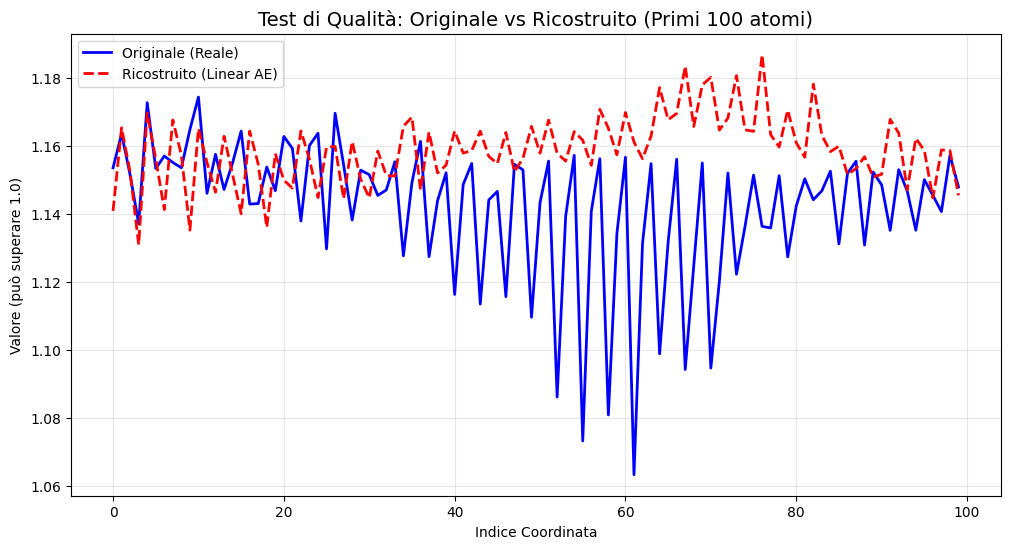

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tensorflow.keras import layers, models
import os

# CONFIGURAZIONE
BASE_PATH = "."  
FILE_COORDS = os.path.join(BASE_PATH, "coordinates_processed.csv")

print("🧪 AVVIO QUALITY CHECK (VERSIONE CORRETTA - LINEAR)...")

# 1. Carichiamo i dati originali
if not os.path.exists(FILE_COORDS):
    raise FileNotFoundError("❌ Manca coordinates_processed.csv!")

df = pd.read_csv(FILE_COORDS)
data = df.values
input_dim = data.shape[1]
latent_dim = 32 

# 2. Ricostruiamo l'Autoencoder (FIX: Linear Output)
inp = layers.Input(shape=(input_dim,))
e = layers.Dense(128, activation='relu')(inp)
e = layers.Dense(64, activation='relu')(e)
latent = layers.Dense(latent_dim, activation='linear')(e)
d = layers.Dense(64, activation='relu')(latent)
d = layers.Dense(128, activation='relu')(d)

# ⚠️ QUESTA È LA RIGA FONDAMENTALE DA CAMBIARE:
out = layers.Dense(input_dim, activation='linear')(d) 
# (Prima c'era 'sigmoid' che bloccava tutto a 1.0)

ae = models.Model(inp, out)
ae.compile(optimizer='adam', loss='mse')

print("⏳ Training rapido per validazione (10 epoche)...")
history = ae.fit(data, data, epochs=10, batch_size=64, verbose=0, shuffle=True)

# 3. VALUTAZIONE 1: LOSS FINALE
final_loss = history.history['loss'][-1]
print(f"\n📊 RISULTATO NUMERICO:")
print(f"   MSE Loss Finale: {final_loss:.6f}")

if final_loss < 0.01:
    print("   ✅ GIUDIZIO: OTTIMO! (Ora ci siamo)")
else:
    print("   ⚠️ GIUDIZIO: ANCORA ALTO (Controlla i dati)")

# 4. VALUTAZIONE 2: GRAFICO RICOSTRUZIONE
idx = 100
original_sample = data[idx]
reconstructed_sample = ae.predict(data[idx:idx+1], verbose=0)[0]

plt.figure(figsize=(12, 6))
limit = 100 
plt.plot(original_sample[:limit], label='Originale (Reale)', color='blue', linewidth=2)
plt.plot(reconstructed_sample[:limit], label='Ricostruito (Linear AE)', color='red', linestyle='--', linewidth=2)

plt.title(f'Test di Qualità: Originale vs Ricostruito (Primi {limit} atomi)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel("Indice Coordinata")
plt.ylabel("Valore (può superare 1.0)")
plt.savefig("quality_check_linear.jpg", dpi=300)
plt.show()

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

class WindowGenerator:
    def __init__(self, input_width, label_width, shift, 
                 train_df, val_df, test_df, 
                 label_columns=None):
        
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        # Gestione delle colonne che vogliamo predire (Target)
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
        
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

        # I parametri della finestra temporale
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        # Calcolo degli indici per tagliare (Slicing)
        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def split_window(self, features):
        # 1. INPUT: Prende i dati del passato (tutte le feature)
        inputs = features[:, self.input_slice, :]
        
        # 2. LABEL: Prende i dati del futuro
        labels = features[:, self.labels_slice, :]
        
        # 3. FILTRO: Se abbiamo specificato colonne target, teniamo solo quelle
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1)

        # Aiutiamo TensorFlow a capire le dimensioni (Shape)
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])

        return inputs, labels

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        # Questa funzione di TF crea le finestre scorrevoli automaticamente
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=True,  # Mescola i pacchetti (fondamentale per il training)
            batch_size=32, # Quante finestre processare insieme
        )
        ds = ds.map(self.split_window)
        return ds

    # Shortcut per ottenere i dataset pronti
    @property
    def train(self): return self.make_dataset(self.train_df)
    @property
    def val(self): return self.make_dataset(self.val_df)
    @property
    def test(self): return self.make_dataset(self.test_df)

    # Funzione extra per vedere un esempio al volo
    @property
    def example(self):
        result = getattr(self, '_example', None)
        if result is None:
            result = next(iter(self.train))
            self._example = result
        return result
    
    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_indices}',
            f'Label indices: {self.label_indices}',
            f'Label column name(s): {self.label_columns}'])

In [ ]:
label_cols = [c for c in train_df.columns if c.startswith("Latent_")]
print("Target latent:", len(label_cols))


Target latent: 32


In [62]:
SHIFT = 10

w30 = WindowGenerator(
    input_width=30,
    label_width=1,
    shift=SHIFT,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=label_cols
)

w60 = WindowGenerator(
    input_width=60,
    label_width=1,
    shift=SHIFT,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=label_cols
)

print("w30:", w30)
print("w60:", w60)

x, y = w30.example
print("Example w30 x:", x.shape, "y:", y.shape)  # (batch,30,96) e (batch,1,32)


w30: Total window size: 40
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
Label indices: [39]
Label column name(s): ['Latent_0', 'Latent_1', 'Latent_2', 'Latent_3', 'Latent_4', 'Latent_5', 'Latent_6', 'Latent_7', 'Latent_8', 'Latent_9', 'Latent_10', 'Latent_11', 'Latent_12', 'Latent_13', 'Latent_14', 'Latent_15', 'Latent_16', 'Latent_17', 'Latent_18', 'Latent_19', 'Latent_20', 'Latent_21', 'Latent_22', 'Latent_23', 'Latent_24', 'Latent_25', 'Latent_26', 'Latent_27', 'Latent_28', 'Latent_29', 'Latent_30', 'Latent_31']
w60: Total window size: 70
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59]
Label indices: [69]
Label column name(s): ['Latent_0', 'Latent_1', 'Latent_2', 'Latent_3', 'Latent_4', 'Latent_5', 'Latent_6', 'Latent_7', 'Latent_8', 'Latent_9', 'Latent_10', 'Latent_11', '

In [63]:
import tensorflow as tf

class Baseline(tf.keras.Model):
    def __init__(self, target_indices):
        super().__init__()
        self.target_indices = tf.constant(target_indices, dtype=tf.int32)

    def call(self, inputs):
        last = inputs[:, -1:, :]  # (batch, 1, features)
        return tf.gather(last, self.target_indices, axis=2)  # (batch, 1, targets)


In [64]:
def eval_baseline(w):
    target_idx = [w.column_indices[c] for c in label_cols]
    b = Baseline(target_idx)
    b.compile(loss="mse", metrics=["mae"])
    val = b.evaluate(w.val, verbose=0)
    test = b.evaluate(w.test, verbose=0)
    print(f"Baseline (input_width={w.input_width}, shift={w.shift})  VAL: loss={val[0]:.6f} mae={val[1]:.6f}  |  TEST: loss={test[0]:.6f} mae={test[1]:.6f}")
    return val, test

baseline_w30 = eval_baseline(w30)
baseline_w60 = eval_baseline(w60)


Baseline (input_width=30, shift=10)  VAL: loss=0.000004 mae=0.001308  |  TEST: loss=0.000005 mae=0.001451
Baseline (input_width=60, shift=10)  VAL: loss=0.000004 mae=0.001309  |  TEST: loss=0.000005 mae=0.001451


In [65]:
from tensorflow.keras import layers
import tensorflow as tf

def build_cnn1d(input_width, num_features, num_targets,
               filters1=64, kernel1=3,
               filters2=64, kernel2=3,
               dropout=0.2, dense_units=64, lr=1e-3):

    model = tf.keras.Sequential([
        layers.Input(shape=(input_width, num_features)),

        # Convoluzioni causali: non guardano il futuro
        layers.Conv1D(filters=filters1, kernel_size=kernel1, padding="causal", activation="relu"),
        layers.Dropout(dropout),

        layers.Conv1D(filters=filters2, kernel_size=kernel2, padding="causal", activation="relu"),
        layers.Dropout(dropout),

        layers.GlobalAveragePooling1D(),

        layers.Dense(dense_units, activation="relu"),
        layers.Dense(num_targets),
        layers.Reshape((1, num_targets))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


In [66]:
import pandas as pd

def train_and_eval(model, w, name, epochs=50):
    early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    history = model.fit(
        w.train,
        validation_data=w.val,
        epochs=epochs,
        callbacks=[early],
        verbose=0
    )
    test_loss, test_mae = model.evaluate(w.test, verbose=0)

    return {
        "model": name,
        "input_width": w.input_width,
        "shift": w.shift,
        "best_val_loss": float(min(history.history["val_loss"])),
        "test_loss": float(test_loss),
        "test_mae": float(test_mae),
        "epochs_ran": len(history.history["loss"])
    }


In [67]:
cnn_configs = [
    {"filters1": 32, "kernel1": 3, "filters2": 32, "kernel2": 3, "dropout": 0.1, "dense_units": 32,  "lr": 1e-3},
    {"filters1": 64, "kernel1": 3, "filters2": 64, "kernel2": 3, "dropout": 0.2, "dense_units": 64,  "lr": 1e-3},
    {"filters1": 64, "kernel1": 5, "filters2": 64, "kernel2": 3, "dropout": 0.3, "dense_units": 128, "lr": 5e-4},
]

results = []

for w in [w30, w60]:
    for i, cfg in enumerate(cnn_configs, start=1):
        model = build_cnn1d(
            input_width=w.input_width,
            num_features=train_df.shape[1],   # 96
            num_targets=len(label_cols),      # 32
            **cfg
        )
        res = train_and_eval(model, w, name=f"CNN1D_cfg{i}", epochs=50)
        results.append(res)
        print(res)

results_df = pd.DataFrame(results).sort_values(["input_width", "test_loss"])
results_df


{'model': 'CNN1D_cfg1', 'input_width': 30, 'shift': 10, 'best_val_loss': 0.008788911625742912, 'test_loss': 0.042203277349472046, 'test_mae': 0.17253325879573822, 'epochs_ran': 7}
{'model': 'CNN1D_cfg2', 'input_width': 30, 'shift': 10, 'best_val_loss': 0.009779802523553371, 'test_loss': 0.036800019443035126, 'test_mae': 0.1559263914823532, 'epochs_ran': 6}
{'model': 'CNN1D_cfg3', 'input_width': 30, 'shift': 10, 'best_val_loss': 0.004475954454392195, 'test_loss': 0.019214661791920662, 'test_mae': 0.11206615716218948, 'epochs_ran': 8}
{'model': 'CNN1D_cfg1', 'input_width': 60, 'shift': 10, 'best_val_loss': 0.005299835465848446, 'test_loss': 0.024497080594301224, 'test_mae': 0.12483318150043488, 'epochs_ran': 8}
{'model': 'CNN1D_cfg2', 'input_width': 60, 'shift': 10, 'best_val_loss': 0.004109254106879234, 'test_loss': 0.029729336500167847, 'test_mae': 0.1463315337896347, 'epochs_ran': 11}
{'model': 'CNN1D_cfg3', 'input_width': 60, 'shift': 10, 'best_val_loss': 0.007645529694855213, 'test_

,model,input_width,shift,best_val_loss,test_loss,test_mae,epochs_ran
2,CNN1D_cfg3,30,10,0.004476,0.019215,0.112066,8
1,CNN1D_cfg2,30,10,0.009780,0.036800,0.155926,6
0,CNN1D_cfg1,30,10,0.008789,0.042203,0.172533,7
3,CNN1D_cfg1,60,10,0.005300,0.024497,0.124833,8
4,CNN1D_cfg2,60,10,0.004109,0.029729,0.146332,11
5,CNN1D_cfg3,60,10,0.007646,0.034934,0.144608,8


Best config: model            CNN1D_cfg3
input_width              30
shift                    10
best_val_loss      0.004476
test_loss          0.019215
test_mae           0.112066
epochs_ran                8
Name: 2, dtype: object


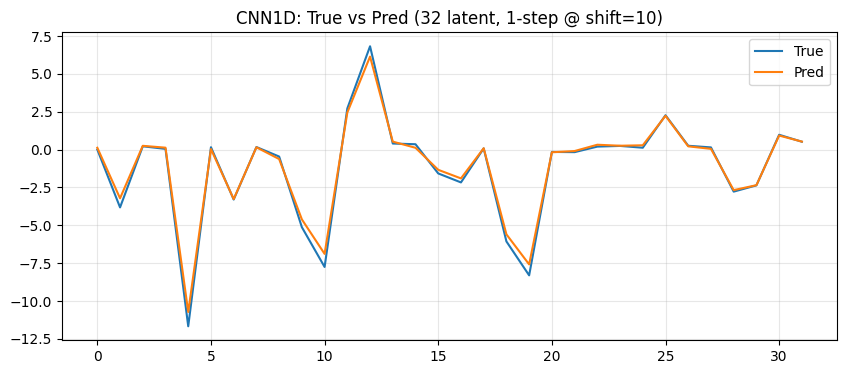

In [68]:
import matplotlib.pyplot as plt
import numpy as np

best_row = results_df.sort_values("test_loss").iloc[0]
print("Best config:", best_row)

# Ricostruisci il best model (se vuoi)
# (in pratica, conserva 'model' quando lo alleni se vuoi riusarlo subito)

x_batch, y_true = next(iter(w30.test))
# se hai ancora l'ultimo model in memoria, usa quello:
y_pred = model.predict(x_batch, verbose=0)

plt.figure(figsize=(10,4))
plt.plot(y_true[0,0,:], label="True")
plt.plot(y_pred[0,0,:], label="Pred")
plt.title("CNN1D: True vs Pred (32 latent, 1-step @ shift=10)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras import layers
import tensorflow as tf

def build_lstm(input_width, num_features, num_targets,
               units=64, dropout=0.2, recurrent_dropout=0.0,
               dense_units=64, lr=1e-3):
    
    model = tf.keras.Sequential([
        layers.Input(shape=(input_width, num_features)),
        layers.LSTM(units, dropout=dropout, recurrent_dropout=recurrent_dropout),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(num_targets),
        layers.Reshape((1, num_targets))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


In [ ]:

def build_lstm(input_width, num_features, num_targets,
               units=64, dropout=0.2, recurrent_dropout=0.0,
               dense_units=64, lr=1e-3):
    
    model = tf.keras.Sequential([
        layers.Input(shape=(input_width, num_features)),
        layers.LSTM(units, dropout=dropout, recurrent_dropout=recurrent_dropout),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(num_targets),
        layers.Reshape((1, num_targets))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


In [54]:
import pandas as pd
import tensorflow as tf

def train_and_eval(model, w, name, epochs=50):
    early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    history = model.fit(
        w.train,
        validation_data=w.val,
        epochs=epochs,
        callbacks=[early],
        verbose=0
    )

    test_loss, test_mae = model.evaluate(w.test, verbose=0)

    return {
        "model": name,
        "input_width": w.input_width,
        "shift": w.shift,
        "best_val_loss": float(min(history.history["val_loss"])),
        "test_loss": float(test_loss),
        "test_mae": float(test_mae),
        "epochs_ran": len(history.history["loss"])
    }


In [55]:
lstm_configs = [
    {"units": 32,  "dropout": 0.1, "recurrent_dropout": 0.0, "dense_units": 32,  "lr": 1e-3},
    {"units": 64,  "dropout": 0.2, "recurrent_dropout": 0.0, "dense_units": 64,  "lr": 1e-3},
    {"units": 128, "dropout": 0.3, "recurrent_dropout": 0.0, "dense_units": 128, "lr": 5e-4},
]


In [56]:
results_lstm = []

for w in [w30, w60]:
    for i, cfg in enumerate(lstm_configs, start=1):
        model = build_lstm(
            input_width=w.input_width,
            num_features=train_df.shape[1],   # 96
            num_targets=len(label_cols),      # 32
            **cfg
        )
        res = train_and_eval(model, w, name=f"LSTM_cfg{i}", epochs=50)
        results_lstm.append(res)
        print(res)

results_lstm_df = pd.DataFrame(results_lstm).sort_values(["input_width", "test_loss"])
results_lstm_df


{'model': 'LSTM_cfg1', 'input_width': 30, 'shift': 10, 'best_val_loss': 1.2784475088119507, 'test_loss': 6.984670162200928, 'test_mae': 1.5795179605484009, 'epochs_ran': 7}
{'model': 'LSTM_cfg2', 'input_width': 30, 'shift': 10, 'best_val_loss': 1.2624813318252563, 'test_loss': 6.831790924072266, 'test_mae': 1.557196855545044, 'epochs_ran': 7}
{'model': 'LSTM_cfg3', 'input_width': 30, 'shift': 10, 'best_val_loss': 1.2562060356140137, 'test_loss': 6.562915325164795, 'test_mae': 1.5353642702102661, 'epochs_ran': 6}
{'model': 'LSTM_cfg1', 'input_width': 60, 'shift': 10, 'best_val_loss': 1.1222896575927734, 'test_loss': 6.395294189453125, 'test_mae': 1.510465383529663, 'epochs_ran': 7}
{'model': 'LSTM_cfg2', 'input_width': 60, 'shift': 10, 'best_val_loss': 1.271125078201294, 'test_loss': 6.58109188079834, 'test_mae': 1.5385737419128418, 'epochs_ran': 6}
{'model': 'LSTM_cfg3', 'input_width': 60, 'shift': 10, 'best_val_loss': 1.276410698890686, 'test_loss': 6.608943462371826, 'test_mae': 1.53

,model,input_width,shift,best_val_loss,test_loss,test_mae,epochs_ran
2,LSTM_cfg3,30,10,1.256206,6.562915,1.535364,6
1,LSTM_cfg2,30,10,1.262481,6.831791,1.557197,7
0,LSTM_cfg1,30,10,1.278448,6.984670,1.579518,7
3,LSTM_cfg1,60,10,1.122290,6.395294,1.510465,7
4,LSTM_cfg2,60,10,1.271125,6.581092,1.538574,6
5,LSTM_cfg3,60,10,1.276411,6.608943,1.539847,6


Best LSTM: model            LSTM_cfg1
input_width             60
shift                   10
best_val_loss      1.12229
test_loss         6.395294
test_mae          1.510465
epochs_ran               7
Name: 3, dtype: object


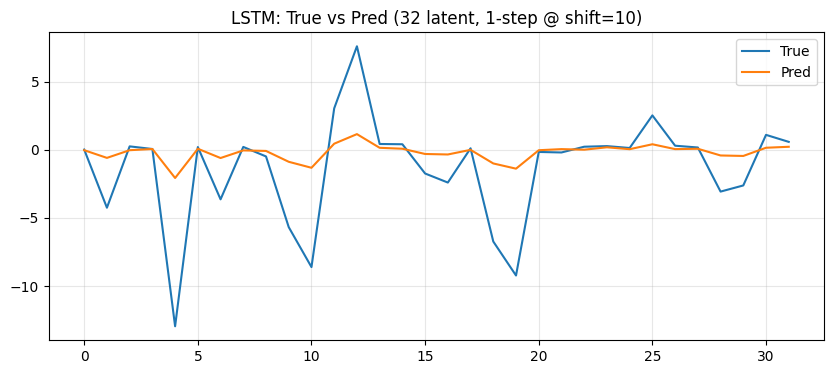

In [57]:
best = results_lstm_df.sort_values("test_loss").iloc[0]
print("Best LSTM:", best)

# ricostruisci la config da best["model"] (cfg1/cfg2/cfg3)
# qui lo facciamo in modo pratico: scegliamo manualmente in base al nome
cfg_map = {
    "LSTM_cfg1": lstm_configs[0],
    "LSTM_cfg2": lstm_configs[1],
    "LSTM_cfg3": lstm_configs[2],
}
best_cfg = cfg_map[best["model"]]

# scegli la window corretta
best_w = w30 if best["input_width"] == 30 else w60

best_model = build_lstm(
    input_width=best_w.input_width,
    num_features=train_df.shape[1],
    num_targets=len(label_cols),
    **best_cfg
)

_ = best_model.fit(best_w.train, validation_data=best_w.val, epochs=best["epochs_ran"], verbose=0)

x_batch, y_true = next(iter(best_w.test))
y_pred = best_model.predict(x_batch, verbose=0)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(y_true[0,0,:], label="True")
plt.plot(y_pred[0,0,:], label="Pred")
plt.title(f"LSTM: True vs Pred (32 latent, 1-step @ shift={best_w.shift})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [69]:
import numpy as np
import pandas as pd

# prendi un batch dal test
x_batch, y_true = next(iter(w60.test))   # usa w60 se la migliore era input_width=60
y_pred = model.predict(x_batch, verbose=0)

# prendo il primo esempio del batch
true_vec = y_true[0,0,:].numpy()
pred_vec = y_pred[0,0,:]

df_cmp = pd.DataFrame({
    "latent": [f"Latent_{i}" for i in range(len(true_vec))],
    "true": true_vec,
    "pred": pred_vec,
})
df_cmp["abs_err"] = (df_cmp["true"] - df_cmp["pred"]).abs()
df_cmp["sq_err"] = (df_cmp["true"] - df_cmp["pred"])**2

# stampa le peggiori 10 (dove sbaglia di più)
print(df_cmp.sort_values("abs_err", ascending=False).head(10).to_string(index=False))

# e le migliori 10 (dove è super preciso)
print("\n--- Migliori 10 ---")
print(df_cmp.sort_values("abs_err", ascending=True).head(10).to_string(index=False))


   latent       true       pred  abs_err   sq_err
Latent_10  -8.301831  -7.801740 0.500091 0.250091
 Latent_1  -4.099594  -3.610330 0.489264 0.239379
Latent_12   7.309820   6.936818 0.373002 0.139131
Latent_19  -8.895497  -8.562173 0.333324 0.111105
 Latent_4 -12.489911 -12.163759 0.326152 0.106375
 Latent_9  -5.482730  -5.163301 0.319429 0.102035
Latent_14   0.380738   0.102722 0.278015 0.077293
 Latent_8  -0.483937  -0.695437 0.211500 0.044732
Latent_24   0.123814   0.322963 0.199149 0.039660
Latent_18  -6.494645  -6.306977 0.187667 0.035219

--- Migliori 10 ---
   latent      true      pred  abs_err   sq_err
 Latent_7  0.189074  0.187170 0.001904 0.000004
Latent_17  0.093210  0.103123 0.009913 0.000098
Latent_30  1.047008  1.067412 0.020404 0.000416
Latent_31  0.552583  0.581948 0.029365 0.000862
Latent_26  0.276862  0.245907 0.030955 0.000958
Latent_23  0.254680  0.288126 0.033446 0.001119
Latent_20 -0.163875 -0.206486 0.042610 0.001816
 Latent_2  0.233002  0.279558 0.046555 0.0021

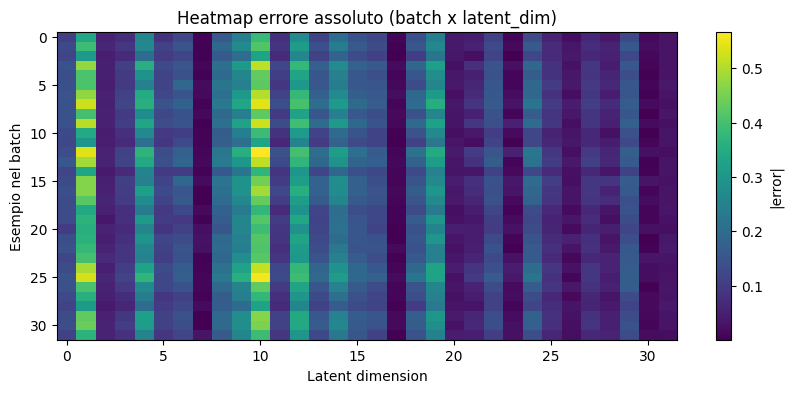

In [70]:
import matplotlib.pyplot as plt

# prendi un batch più grande se vuoi
x_batch, y_true = next(iter(w60.test))
y_pred = model.predict(x_batch, verbose=0)

true_mat = y_true[:,0,:].numpy()     # (batch, 32)
pred_mat = y_pred[:,0,:]             # (batch, 32)
err_mat  = np.abs(true_mat - pred_mat)

plt.figure(figsize=(10,4))
plt.imshow(err_mat, aspect="auto")
plt.colorbar(label="|error|")
plt.title("Heatmap errore assoluto (batch x latent_dim)")
plt.xlabel("Latent dimension")
plt.ylabel("Esempio nel batch")
plt.show()


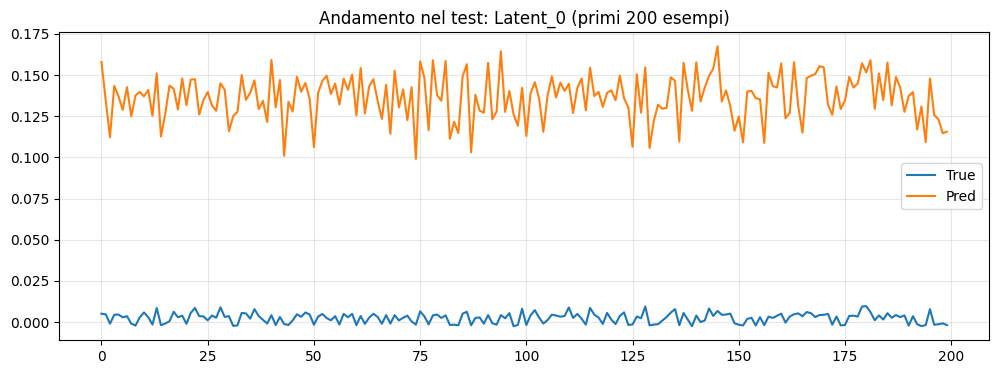

In [71]:
import matplotlib.pyplot as plt

# accumula un po’ di predizioni dal test
ys_true, ys_pred = [], []
for i, (xb, yb) in enumerate(w60.test.take(20)):   # 20 batch ~ 640 esempi
    yp = model.predict(xb, verbose=0)
    ys_true.append(yb[:,0,:].numpy())
    ys_pred.append(yp[:,0,:])

Yt = np.concatenate(ys_true, axis=0)  # (N,32)
Yp = np.concatenate(ys_pred, axis=0)  # (N,32)

dim = 0  # scegli la latente che vuoi
plt.figure(figsize=(12,4))
plt.plot(Yt[:200, dim], label="True")
plt.plot(Yp[:200, dim], label="Pred")
plt.title(f"Andamento nel test: Latent_{dim} (primi 200 esempi)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


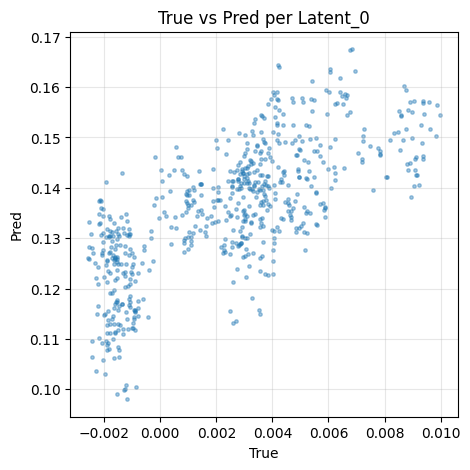

In [72]:
import matplotlib.pyplot as plt

# usa Yt, Yp del blocco precedente (o rifalli)
dim = 0
plt.figure(figsize=(5,5))
plt.scatter(Yt[:, dim], Yp[:, dim], s=6, alpha=0.4)
plt.title(f"True vs Pred per Latent_{dim}")
plt.xlabel("True")
plt.ylabel("Pred")
plt.grid(True, alpha=0.3)
plt.show()
